Sanity:
  xp range: 0.4 0.40074580811003474
  xn range: 0.799254191889965 0.8
  ceL min : 999.637795630557  ceR min: 1000.0


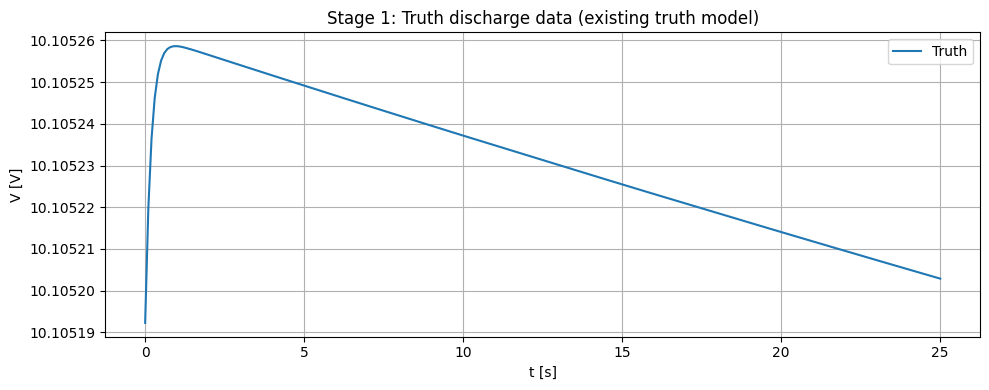

Shapes: t (251,) U (251, 1) Y (251, 1)

Stage 2: Fit ONLY surrogate Z (poly) + Rcell, A and B fixed to truth
Stage 2 pre-fit max|err|: 0.05972970875702188


  0%|                        |

Solving NLP with Adam (46 optimization variables) ...


100%|████████████████████████|
    f =   0.000001, f* =  0.000001, |grad f| =  0.001657, iter = 1500


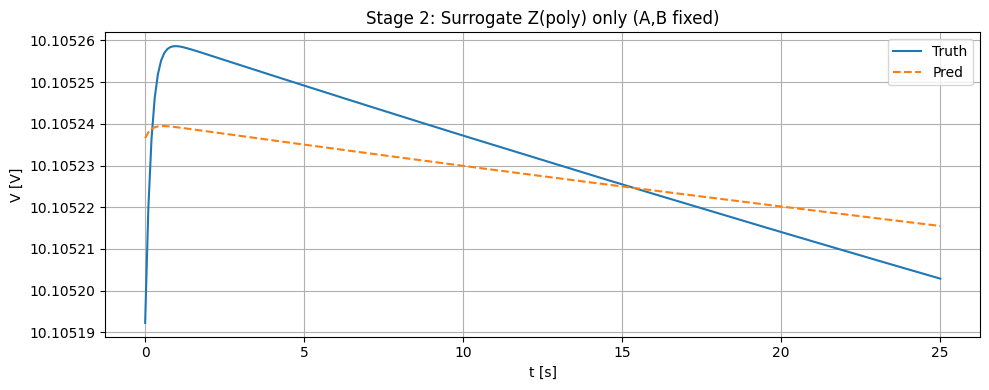


Stage 2 (train) error summary:
  RMSE  = 1.05683e-05 V
  MAE   = 8.80292e-06 V
  P95   = 1.85235e-05 V
  P99   = 1.94164e-05 V
  MAX   = 4.43345e-05 V

Stage 2 learned:
  POLY_DEG=6, N_POLY=28, USE_I_FEATURES=True
  thetaZ_hat shape: (31,)
  Rcell_hat: 0.009921346930536555

################################################################################
SWEEP DEGREE = 3
################################################################################


  0%|                        |

Solving NLP with Adam (28 optimization variables) ...


TypeError: dot_general requires contracting dimensions to have the same shape, got (28,) and (10,).

In [ ]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# UPDATED: Replace nonlinear Z part of V with a POLY surrogate
#
# Z_truth(x) = Ns * [(Up-Un) + BV + dphi_e]        (truth generator unchanged)
#
# New surrogate (PACK-SCALE):
#   Z_hat_pack(x, I) = Phi_poly(xp,xn) @ theta_poly
#                      + k_ln * ln(ceR/ceL)
#                      + kI  * I + kI2 * I^2         (optional; helps if you vary I)
#
# Then voltage in JAX model:
#   V_pack_hat = Z_hat_pack(x,I)  - Ns * I * Rcell
#
# Stages (as supervisor asked):
#   Stage 1) Generate truth discharge data from existing model (UNCHANGED)
#   Stage 2) Freeze A,B to truth. Identify ONLY surrogate voltage params (+R)
#   Stage 3) Identify EVERYTHING: A(θ1..θ7), B(θ8..θ11), surrogate params (+R)
#
# Plus: Dynamic replacement validation
#   - Train Stage 2 on dataset 1 (e.g., constant current)
#   - Evaluate Stage 2 fitted surrogate on dataset 2 (different current or SOC)
#   If it generalizes, you can trust it as a Z replacement in identification.
# =========================================================


# %% ======================================================
# Cell 0 — Imports + plotting
# =========================================================
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker


def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()


def summarize_err(y_true: np.ndarray, y_pred: np.ndarray, name=""):
    err = np.asarray(y_pred).reshape(-1) - np.asarray(y_true).reshape(-1)
    rmse = float(np.sqrt(np.mean(err**2)))
    mae  = float(np.mean(np.abs(err)))
    p95  = float(np.percentile(np.abs(err), 95))
    p99  = float(np.percentile(np.abs(err), 99))
    mx   = float(np.max(np.abs(err)))
    print(f"\n{name} error summary:")
    print(f"  RMSE  = {rmse:.6g} V")
    print(f"  MAE   = {mae:.6g} V")
    print(f"  P95   = {p95:.6g} V")
    print(f"  P99   = {p99:.6g} V")
    print(f"  MAX   = {mx:.6g} V")
    return dict(rmse=rmse, mae=mae, p95=p95, p99=p99, max_abs=mx)


# %% ======================================================
# Cell 1 — Index map + Config (TRUTH generator stays same)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}


@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3


# %% ======================================================
# Cell 2 — OCVs + TRUTH diffusion blocks (unchanged)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))


def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b


def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b


def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names


# %% ======================================================
# Cell 3 — Helpers + TRUTH voltage (unchanged)
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))


def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    """
    TRUTH voltage (unchanged): (Up-Un)+BV+dphi_e+ohmic, times N_series.
    """
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)


# %% ======================================================
# Cell 4 — Nonlinear IOSystem + data generation (unchanged)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full


def generate_profile_data(
    cfg: Config,
    I_profile: np.ndarray,   # shape (N,)
    T: np.ndarray,           # shape (N,)
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    """
    A small helper for the "generalization gate": simulate with a time-varying current.
    Uses the SAME truth model, but provides u(t)=I_profile.
    """
    I_profile = np.asarray(I_profile, dtype=float).reshape(-1)
    T = np.asarray(T, dtype=float).reshape(-1)
    assert I_profile.shape[0] == T.shape[0]

    # cfg uses I_dyn only if u is empty; here u is provided, so ok.
    cfg.I_for_voltage = float(I_profile[0])  # just to initialize (terminal_voltage_truth uses I argument anyway)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    def _update(t, x, u, params):
        A = params["A"]; B = params["B"]; cfg = params["cfg"]
        I = float(np.asarray(u).reshape(-1)[0])
        return A @ x + B[:, 0] * I

    def _output(t, x, u, params):
        cfg = params["cfg"]
        I = float(np.asarray(u).reshape(-1)[0])
        V = terminal_voltage_truth(x, cfg, I=I)
        return np.hstack([x, V])

    battery_nl = ct.nlsys(
        _update, _output,
        name="battery_truth_profile",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack"],
        inputs=1,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, I_profile.reshape(1, -1), X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = I_profile.reshape(-1, 1)
    return T, U, X, V, Y_full


# %% ======================================================
# Cell 5 — Stage 1: Generate truth data (same as you have)
# =========================================================
CFG = Config()

t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=25,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)


# %% ======================================================
# Cell 6 — JAX imports + safe transforms
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)


def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor


# %% ======================================================
# Cell 7 — A(θ1..θ7), B(θ8..θ11) builders (unchanged)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    A = jnp.zeros((14, 14), dtype=DTYPE)

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B


# %% ======================================================
# Cell 8 — NEW POLY surrogate for Z (this is the plug-in)
# =========================================================
def poly_terms_2d(deg: int):
    """
    Terms are xp^i * xn^j with i+j <= deg (total degree).
    Returns list of (i,j) in a fixed order.
    """
    terms = []
    for i in range(deg + 1):
        for j in range(deg + 1 - i):
            terms.append((i, j))
    return terms

POLY_DEG = 6
TERMS_2D = poly_terms_2d(POLY_DEG)
N_POLY = len(TERMS_2D)

USE_I_FEATURES = True   # include kI*I + kI2*I^2 features
# Parameter layout for surrogate (Stage 2 & 3):
#   theta_poly: length N_POLY
#   k_ln: scalar
#   kI, kI2: scalars (if USE_I_FEATURES)
#   raw_R: scalar (positive via pos)
#
# TOTAL:
#   n_thetaZ = N_POLY + 1 + (2 if USE_I_FEATURES else 0)


@jax.jit
def poly_features_from_x(x: jnp.ndarray) -> jnp.ndarray:
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)

    cols = []
    for (i, j) in TERMS_2D:
        cols.append((xp ** i) * (xn ** j))
    return jnp.stack(cols, axis=0)  # (N_POLY,)


@jax.jit
def ln_ce_ratio_from_x(x: jnp.ndarray) -> jnp.ndarray:
    ceL_raw = x[IDX["ce_left"]]
    ceR_raw = x[IDX["ce_right"]]
    ceL = (DTYPE(CFG.ce0) + ceL_raw) if CFG.ce_is_deviation else ceL_raw
    ceR = (DTYPE(CFG.ce0) + ceR_raw) if CFG.ce_is_deviation else ceR_raw
    ceL = jnp.maximum(ceL, 1e-12)
    ceR = jnp.maximum(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (CFG.ln_orientation == "right_over_left") else (ceL / ceR)
    return jnp.log(jnp.maximum(ln_arg, 1e-12))


def unpack_thetaZ(thetaZ: jnp.ndarray):
    """
    thetaZ packs:
      theta_poly (N_POLY)
      k_ln (1)
      (kI,kI2) optional
    """
    thetaZ = thetaZ.reshape(-1)
    theta_poly = thetaZ[:N_POLY]
    k_ln = thetaZ[N_POLY]
    if USE_I_FEATURES:
        kI  = thetaZ[N_POLY + 1]
        kI2 = thetaZ[N_POLY + 2]
        return theta_poly, k_ln, kI, kI2
    else:
        return theta_poly, k_ln, None, None


@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    """
    Returns PACK-SCALE Z_hat(x,I).
    """
    phi = poly_features_from_x(x)      # (N_POLY,)
    lnratio = ln_ce_ratio_from_x(x)    # scalar

    theta_poly, k_ln, kI, kI2 = unpack_thetaZ(thetaZ)

    z = jnp.dot(phi, theta_poly) + k_ln * lnratio
    if USE_I_FEATURES:
        z = z + kI * I + kI2 * (I**2)
    return z


@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    """
    V_pack_hat = Z_hat_pack(x,I) - Ns * I * Rcell
    """
    Zhat_pack = zhat_pack_from_thetaZ(x, I, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    Vohm_pack = -DTYPE(CFG.N_series) * I * Rcell
    return Zhat_pack + Vohm_pack


def make_thetaZ0_from_data(t_np, U_np, Y_np):
    """
    Stable init:
      - theta_poly all zeros
      - k_ln ~ 0
      - kI,kI2 ~ 0
      - add constant term into theta_poly corresponding to (i=0,j=0) so mean(V)
    """
    thetaZ0 = np.zeros(N_POLY + 1 + (2 if USE_I_FEATURES else 0), dtype=np.float64)
    vmean = float(np.mean(Y_np[:, 0]))
    # constant basis term is xp^0 * xn^0, which is the first term in TERMS_2D
    thetaZ0[0] = vmean
    return thetaZ0


# %% ======================================================
# Cell 9 — Stage 2: fit ONLY surrogate voltage (A,B fixed)
# =========================================================
print("\n==============================")
print("Stage 2: Fit ONLY surrogate Z (poly) + Rcell, A and B fixed to truth")
print("==============================")

_, A_true_np, B_true_np, _, _ = assemble_system(CFG)
A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

thetaZ0 = make_thetaZ0_from_data(t_np, U_np, Y_np)
raw_R0 = np.array([np.log(1e-2)], dtype=np.float64)  # unconstrained; pos() makes it > 0


@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ, raw_R) = params
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R[0])
    return jnp.array([V], dtype=DTYPE)


modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=1500, lbfgs_epochs=0, adam_eta=1e-3)

modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
print("Stage 2 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage2) - Y_np))))

modelZ.fit(Y_np, U_np, t_np)

Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2: Surrogate Z(poly) only (A,B fixed)")
summarize_err(Y_np, Yhat_stage2, name="Stage 2 (train)")

thetaZ_hat = np.asarray(modelZ.params[0]).reshape(-1)
raw_R_hat = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat = float(np.asarray(pos(jnp.array(raw_R_hat, dtype=DTYPE), 1e-12)))

print("\nStage 2 learned:")
print(f"  POLY_DEG={POLY_DEG}, N_POLY={N_POLY}, USE_I_FEATURES={USE_I_FEATURES}")
print("  thetaZ_hat shape:", thetaZ_hat.shape)
print("  Rcell_hat:", R_hat)


# ======================================================
# Degree sweep (Stage 2 train + generalization)
# ======================================================

def run_stage2_for_degree(POLY_DEG: int, use_I_features: bool = True):
    global TERMS_2D, N_POLY, USE_I_FEATURES

    # rebuild polynomial basis
    TERMS_2D = poly_terms_2d(POLY_DEG)
    N_POLY = len(TERMS_2D)
    USE_I_FEATURES = bool(use_I_features)

    # re-init params for this degree
    thetaZ0 = make_thetaZ0_from_data(t_np, U_np, Y_np)
    raw_R0 = np.array([np.log(1e-2)], dtype=np.float64)

    # re-create model (so shapes match new thetaZ length)
    modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
    modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

    try:
        modelZ.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
    except TypeError:
        modelZ.loss(rho_x0=0.0, rho_th=1e-8)

    modelZ.optimization(adam_epochs=1500, lbfgs_epochs=0, adam_eta=1e-3)

    modelZ.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=float(t_np[1] - t_np[0]) / 50.0,
        max_steps=5_000_000,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
    )

    modelZ.fit(Y_np, U_np, t_np)
    Yhat_train, _ = modelZ.predict(modelZ.x0, U_np, t_np)
    met_train = summarize_err(Y_np, Yhat_train, name=f"Stage 2 train (deg={POLY_DEG})")

    thetaZ_hat = np.asarray(modelZ.params[0]).reshape(-1)
    raw_R_hat = float(np.asarray(modelZ.params[1]).reshape(-1)[0])

    # ---- Generalization dataset 1: CC but different start SOC ----
    t_cc, U_cc, X_cc, Y_cc, _ = generate_discharge_data(
        CFG, I_const=2.0, sim_t_end=25, sim_dt=0.1, theta_n0=0.75, theta_p0=0.45, ce0=0.0
    )
    t_cc = np.asarray(t_cc, dtype=np.float64).reshape(-1)
    U_cc = np.asarray(U_cc, dtype=np.float64).reshape(-1, 1)
    Y_cc = np.asarray(Y_cc, dtype=np.float64).reshape(-1, 1)

    model_eval1 = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
    model_eval1.init(params=[thetaZ_hat.astype(np.float64), np.array([raw_R_hat], dtype=np.float64)],
                     x0=np.array(X_cc[0], dtype=np.float64))
    model_eval1.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=float(t_cc[1] - t_cc[0]) / 50.0,
        max_steps=5_000_000,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
    )
    Yhat_cc, _ = model_eval1.predict(model_eval1.x0, U_cc, t_cc)
    met_cc = summarize_err(Y_cc, Yhat_cc, name=f"Stage 2 generalize CC-x0 (deg={POLY_DEG})")

    # ---- Generalization dataset 2: pulsed profile ----
    T2 = np.arange(0.0, 25.0 + 0.1, 0.1)
    I_prof = 2.0 * np.ones_like(T2)
    I_prof[(T2 > 5.0) & (T2 <= 8.0)] = 4.0
    I_prof[(T2 > 12.0) & (T2 <= 14.0)] = 1.0
    I_prof[(T2 > 18.0) & (T2 <= 20.0)] = 3.5

    t2, U2, X2, Y2, _ = generate_profile_data(
        CFG, I_profile=I_prof, T=T2, theta_n0=0.78, theta_p0=0.42, ce0=0.0
    )
    t2 = np.asarray(t2, dtype=np.float64).reshape(-1)
    U2 = np.asarray(U2, dtype=np.float64).reshape(-1, 1)
    Y2 = np.asarray(Y2, dtype=np.float64).reshape(-1, 1)

    model_eval2 = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
    model_eval2.init(params=[thetaZ_hat.astype(np.float64), np.array([raw_R_hat], dtype=np.float64)],
                     x0=np.array(X2[0], dtype=np.float64))
    model_eval2.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=float(t2[1] - t2[0]) / 50.0,
        max_steps=5_000_000,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
    )
    Yhat2, _ = model_eval2.predict(model_eval2.x0, U2, t2)
    met_pulse = summarize_err(Y2, Yhat2, name=f"Stage 2 generalize pulse (deg={POLY_DEG})")

    return dict(
        deg=POLY_DEG,
        n_poly=N_POLY,
        n_thetaZ=(N_POLY + 1 + (2 if USE_I_FEATURES else 0)),
        train=met_train,
        gen_cc=met_cc,
        gen_pulse=met_pulse,
    )


# ---- Run sweep ----
degrees = [3, 4, 5, 6, 7, 8, 9, 10]
sweep = []
for d in degrees:
    print("\n" + "#"*80)
    print(f"SWEEP DEGREE = {d}")
    print("#"*80)
    sweep.append(run_stage2_for_degree(d, use_I_features=True))

print("\n" + "="*80)
print("SWEEP SUMMARY (look at GEN_CC first, then GEN_PULSE)")
print("="*80)
for r in sweep:
    print(
        f"deg={r['deg']:2d}  Npoly={r['n_poly']:3d}  NthetaZ={r['n_thetaZ']:3d} | "
        f"GEN_CC p95={r['gen_cc']['p95']:.3e} max={r['gen_cc']['max_abs']:.3e} | "
        f"GEN_PULSE p95={r['gen_pulse']['p95']:.3e} max={r['gen_pulse']['max_abs']:.3e}"
    )


# %% ======================================================
# Cell 10 — Stage 2 replacement gate: generalization test
#   (same fitted surrogate, new dataset; no refit)
# =========================================================
print("\n==============================")
print("Stage 2 Generalization Gate: evaluate learned surrogate on NEW data")
print("==============================")

# Example "new" dataset: pulsed current profile (still short, same model)
T2 = np.arange(0.0, 25.0 + 0.1, 0.1)
I_base = 2.0
I_prof = I_base * np.ones_like(T2)
I_prof[(T2 > 5.0) & (T2 <= 8.0)] = 4.0
I_prof[(T2 > 12.0) & (T2 <= 14.0)] = 1.0
I_prof[(T2 > 18.0) & (T2 <= 20.0)] = 3.5

t2, U2, X2, Y2, _ = generate_profile_data(
    CFG, I_profile=I_prof, T=T2, theta_n0=0.78, theta_p0=0.42, ce0=0.0
)

t2_np = np.asarray(t2, dtype=np.float64).reshape(-1)
U2_np = np.asarray(U2, dtype=np.float64).reshape(-1, 1)
Y2_np = np.asarray(Y2, dtype=np.float64).reshape(-1, 1)

# Build a "frozen" model with the fitted Stage-2 params, then predict on dataset 2
modelZ_eval = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ_eval.init(params=[thetaZ_hat.astype(np.float64), np.array([raw_R_hat], dtype=np.float64)],
                 x0=np.array(X2[0], dtype=np.float64))
modelZ_eval.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t2_np[1] - t2_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)
Y2_hat, _ = modelZ_eval.predict(modelZ_eval.x0, U2_np, t2_np)

plot_voltage(t2_np, Y2_np, Y2_hat, title="Stage 2: Generalization check (no refit)")
summarize_err(Y2_np, Y2_hat, name="Stage 2 (generalization)")

print("\nIf Stage 2 train + generalization errors are small => your surrogate is a valid Z replacement for SysID.")


# %% ======================================================
# Cell 11 — Stage 3: fit FULL A,B + surrogate params from RANDOM init
# =========================================================
print("\n==============================")
print("Stage 3: Fit FULL A,B + surrogate Z(poly) + R from RANDOM init")
print("==============================")

# Full parameter vector:
#   raw_theta length = 7 (rawA) + 4 (rawB) + n_thetaZ + 1 (raw_R)
N_THETAZ = N_POLY + 1 + (2 if USE_I_FEATURES else 0)
N_RAW = 7 + 4 + N_THETAZ + 1

def unpack_full(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    thetaZ = raw_theta[11:11+N_THETAZ]
    raw_R = raw_theta[11+N_THETAZ]
    thetaA = jnp.exp(rawA)   # enforce positivity
    thetaB = rawB            # signed
    return thetaA, thetaB, thetaZ, raw_R


@jax.jit
def state_fcn_full(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_full(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, raw_R = unpack_full(raw_theta)
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R)
    return jnp.array([V], dtype=DTYPE)


seed = 0
rng = np.random.default_rng(seed)
raw_init = rng.normal(0.0, 0.4, size=(N_RAW,)).astype(np.float64)  # moderate to avoid exp blowup

model_full = CTModel(14, 1, 1, state_fcn=state_fcn_full, output_fcn=output_fcn_full)
model_full.init(params=[raw_init], x0=np.array(X[0], dtype=np.float64))

try:
    model_full.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    model_full.loss(rho_x0=0.0, rho_th=1e-8)

model_full.optimization(adam_epochs=1500, lbfgs_epochs=0, adam_eta=1e-3)

model_full.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model_full.predict(model_full.x0, U_np, t_np)
print("Stage 3 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage3) - Y_np))))

model_full.fit(Y_np, U_np, t_np)

Yhat_stage3, _ = model_full.predict(model_full.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage3, title="Stage 3: FULL fit (A,B + surrogate Z(poly))")
summarize_err(Y_np, Yhat_stage3, name="Stage 3 (train)")

raw_hat = np.asarray(model_full.params[0]).reshape(-1)
thetaA_hat = np.exp(raw_hat[0:7])
thetaB_hat = raw_hat[7:11]
thetaZ_hat3 = raw_hat[11:11+N_THETAZ]
raw_R_hat3  = float(raw_hat[11+N_THETAZ])
R_hat3 = float(np.asarray(pos(jnp.array(raw_R_hat3, dtype=DTYPE), 1e-12)))

print("\nStage 3 learned:")
print("  thetaA_hat (θ1..θ7) =", thetaA_hat)
print("  thetaB_hat (θ8..θ11)=", thetaB_hat)
print("  thetaZ_hat shape     =", thetaZ_hat3.shape, f"(N_THETAZ={N_THETAZ})")
print("  Rcell_hat            =", R_hat3)


# %% ======================================================
# Cell 12 — What to conclude (decision rule)
# =========================================================
print("\n" + "="*80)
print("DECISION RULE: can this surrogate replace Z in identification?")
print("="*80)
print(
    "You can replace Z in SysID if:\n"
    "  (1) Stage 2 (A,B frozen) fits truth well (low RMSE/P95/MAX).\n"
    "      - If Stage 2 fails, it is NOT a good Z replacement.\n"
    "  (2) Stage 2 generalizes on a new dataset (different I profile or SOC).\n"
    "      - If it overfits and fails here, it is NOT safe for identification.\n"
    "  (3) With that surrogate, Stage 3 becomes easier / more stable than with the stiff tanh surrogate.\n"
    "\nPractical acceptance (tune for your project):\n"
    "  - Stage 2 train:      P95 <= 5 mV, MAX <= 20 mV\n"
    "  - Stage 2 generalize: P95 <= 10 mV, MAX <= 40 mV\n"
    "  - Residuals: no obvious structured bias over time\n"
)

Sanity:
  xp range: 0.4 0.40074580811003474
  xn range: 0.799254191889965 0.8
  ceL min : 999.637795630557  ceR min: 1000.0


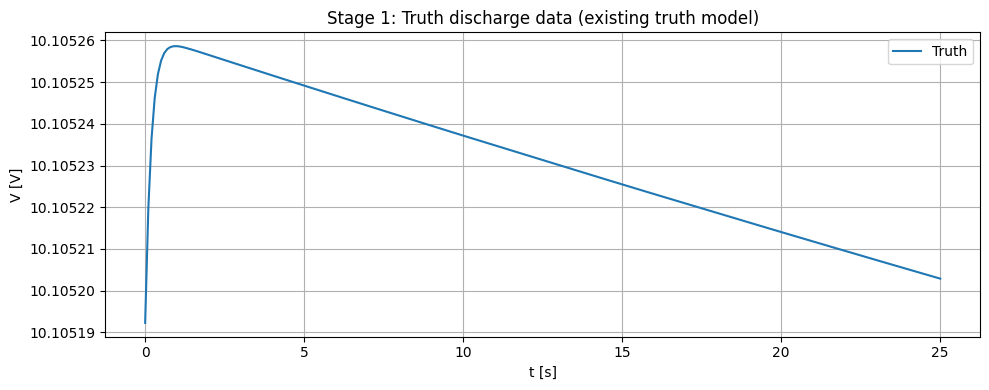

Shapes: t (251,) U (251, 1) Y (251, 1)

CFG-based reference θ0 (for sanity / printing):
  θ01 = 0.0004
  θ02 = 0.0004
  θ03 = 3.856
  θ04 = 1.19012
  θ05 = 6.025
  θ06 = 1.19012
  θ07 = 3.856
  θ08 = -0.0829142
  θ09 = 0.0829142
  θ10 = -0.85678
  θ11 = 0.85678
  θ12 = 4.15
  θ13 = -0.12
  θ14 = 0.6
  θ15 = 0.08
  θ16 = 0.1
  θ17 = 0.8
  θ18 = 0.5
  θ19 = 0.04
  θ20 = 2.99105
  θ21 = 2.99105
  θ22 = 0.0318588
  θ23 = 4.501e-05
  θ24 = 0.0513852

Stage 2: Fit ONLY V (θ12..θ24), A and B fixed to truth
Stage 2 pre-fit max|err|: 3.481543543346154


  0%|                        |

Solving NLP with Adam (27 optimization variables) ...


100%|████████████████████████|
    f =   0.000000, f* =  0.000000, |grad f| =  0.000000, iter = 1200


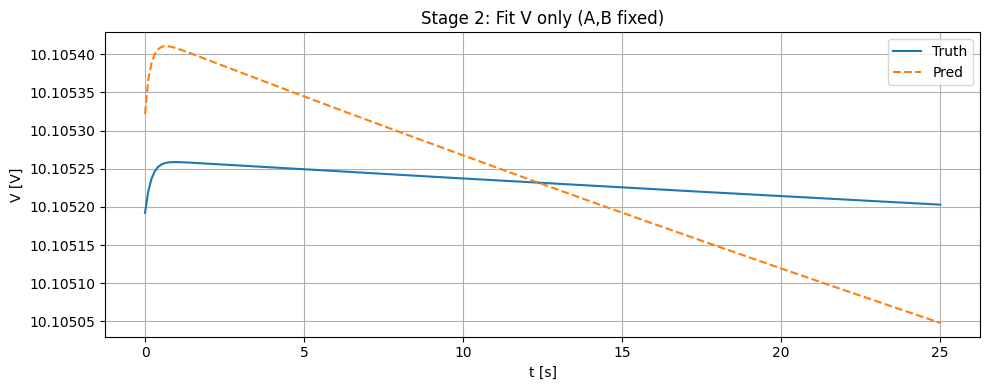


Stage 2 learned θ12..θ24:
  θ12 = 4.39395
  θ13 = -0.416078
  θ14 = 0.892303
  θ15 = -0.259704
  θ16 = -0.143953
  θ17 = 0.563539
  θ18 = 0.722017
  θ19 = 0.208038
  θ20 = 2.7469
  θ21 = 3.2208
  θ22 = 0.276148
  θ23 = -0.237338
  θ24 = -0.133031
Stage 2 stats:
  max|err|: 0.00015486958038835041
  MSE     : 8.375096106354573e-09

Stage 3: Fit FULL θ1..θ24 from RANDOM init (A,B,V all free)
Stage 3 pre-fit max|err|: 14.629703973236483


  0%|                        |

Solving NLP with Adam (38 optimization variables) ...


100%|████████████████████████|
    f =   0.000140, f* =  0.000140, |grad f| =  0.042087, iter = 1200


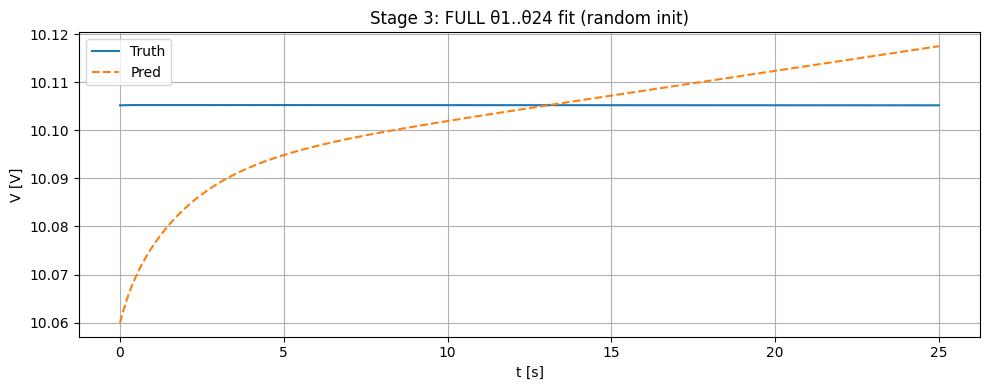


Stage 3 learned θ_hat (interpreted):
  θ01 = 1.06086
  θ02 = 0.336591
  θ03 = 0.475977
  θ04 = 0.364776
  θ05 = 0.257482
  θ06 = 0.372638
  θ07 = 0.596616
  θ08 = -0.270862
  θ09 = -1.20313
  θ10 = -1.62611
  θ11 = 0.63634
  θ12 = 0.825812
  θ13 = -1.19125
  θ14 = 0.742094
  θ15 = -0.636173
  θ16 = -1.17128
  θ17 = -1.09988
  θ18 = -0.928015
  θ19 = -0.628076
  θ20 = -0.359346
  θ21 = 0.678751
  θ22 = 1.71564
  θ23 = -1.0903
  θ24 = 0.275627

Stage 3 stats:
  max|err|: 0.04525156143311726
  MSE     : 0.00014350839415008264


In [8]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# What your supervisor asked (coded as stages):
#   Stage 1) Generate synthetic "truth" discharge data from your existing model
#            (Config + control.nlsys + terminal_voltage).
#
#   Stage 2) Keep A and B EXACTLY equal to the truth A_true, B_true.
#            Identify ONLY V parameters (θ12..θ24) using jax-sysid.
#
#   Stage 3) Identify EVERYTHING: A(θ1..θ7), B(θ8..θ11), V(θ12..θ24).
#            Start from RANDOM initialization (your request) to see if it converges.
#
# Notes:
#   - This follows your constant-current truth generator.
#   - Same state layout: cn(4), cp(4), ce(6) => 14 states.
#   - Identifiability can be ugly with constant-current; Stage 3 may fail or find weird solutions.
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage(x: np.ndarray, cfg: Config, I: float | None = None, return_terms: bool = False):
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell

    if not return_terms:
        return float(V_pack)

    return float(V_pack), {
        "Up": Up, "Un": Un, "Udiff": Up - Un,
        "eta_p": float(eta_p), "eta_n": float(eta_n), "eta_combo": float(eta_combo),
        "dphi_e": float(dphi_e), "ohmic": float(ohmic), "I_use": float(I_use),
        "xp": float(xp), "xn": float(xn), "ceL": float(ceL), "ceR": float(ceR),
        "I0p": float(I0p), "I0n": float(I0n),
        "R_el": electrolyte_resistance(cfg), "R_film": film_resistance(cfg),
    }

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage(x, cfg, I=I, return_terms=False)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data (existing truth model)
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=25,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# --------- safe transforms ----------
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    """
    thetaA = [θ1..θ7] with θi > 0
    A is 14x14 block structure: cn(4), cp(4), ce(6)
    """
    th1, th2, th3, th4, th5, th6, th7 = thetaA

    A = jnp.zeros((14, 14), dtype=DTYPE)

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    """
    thetaB = [θ8, θ9, θ10, θ11]
    B is 14x1:
      cn: last node gets 6θ8
      cp: last node gets 6θ9
      ce: first two get θ10; last two get θ11
    """
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# Voltage model θ12..θ24 (Stage 2 and Stage 3)
# =========================================================
@jax.jit
def voltage_from_theta12_24(x: jnp.ndarray, I: jnp.ndarray, thetaV: jnp.ndarray) -> jnp.ndarray:
    th12, th13, th14, th15, th16, th17, th18, th19, th20, th21, th22, th23, th24 = thetaV

    xp = jnp.clip(x[7] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[3] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)

    # Up = θ12 + θ13*tanh((xp-θ14)/θ15)
    # Un = θ16 + θ17*(1/(1+exp(-(xn-θ18)/θ19)))
    wp = pos(th15, 1e-6)
    wn = pos(th19, 1e-6)
    Up = th12 + th13 * jnp.tanh((xp - th14) / wp)
    Un = th16 + th17 * (1.0 / (1.0 + jnp.exp(-(xn - th18) / wn)))

    # electrolyte endpoints
    ceL_raw = x[8]
    ceR_raw = x[13]
    ceL = (DTYPE(CFG.ce0) + ceL_raw) if CFG.ce_is_deviation else ceL_raw
    ceR = (DTYPE(CFG.ce0) + ceR_raw) if CFG.ce_is_deviation else ceR_raw
    ceL = jnp.maximum(ceL, 1e-12)
    ceR = jnp.maximum(ceR, 1e-12)
    ce_avg = jnp.clip(0.5 * (ceL + ceR), 1e-12, 1e12)

    xp_eff = jnp.clip(xp, DTYPE(CFG.theta_guard), 1.0 - DTYPE(CFG.theta_guard))
    xn_eff = jnp.clip(xn, DTYPE(CFG.theta_guard), 1.0 - DTYPE(CFG.theta_guard))

    # BV denom scales
    Gamma_p = pos(th20, 1e-12)
    Gamma_n = pos(th21, 1e-12)

    s_p = jnp.sqrt(ce_avg) * jnp.sqrt(xp_eff * (1.0 - xp_eff))
    s_n = jnp.sqrt(ce_avg) * jnp.sqrt(xn_eff * (1.0 - xn_eff))

    denom_p = Gamma_p * s_p + 1e-18
    denom_n = Gamma_n * s_n + 1e-18

    # BV prefactor (positive)
    kappa_hat = pos(th24, 1e-12)
    eta_p = DTYPE(CFG.bv_scale) * kappa_hat * jnp.arcsinh(I / denom_p)
    eta_n = DTYPE(CFG.bv_scale) * kappa_hat * jnp.arcsinh(I / denom_n)
    eta_combo = (eta_p - eta_n) if (CFG.eta_mode == "diff") else (eta_p + eta_n)

    # electrolyte log term: θ22 * ln(ceR/ceL)
    ln_arg = (ceR / ceL) if (CFG.ln_orientation == "right_over_left") else (ceL / ceR)
    Ve = th22 * jnp.log(jnp.maximum(ln_arg, 1e-12))

    # ohmic: -I * θ23 (positive)
    Rcell_hat = pos(th23, 1e-12)
    Vohm = -I * Rcell_hat

    V_cell = (Up - Un) + eta_combo + Ve + Vohm
    return DTYPE(CFG.N_series) * V_cell

# =========================================================
# Utility: make "CFG-based" theta0 (for printing / optional init)
# =========================================================
def make_theta0_from_cfg(cfg: Config, X0_for_gamma: np.ndarray) -> np.ndarray:
    # θ1..θ2
    th1 = cfg.Dn / (cfg.Rn**2)
    th2 = cfg.Dp / (cfg.Rp**2)

    # θ3..θ7 electrolyte scalings
    K = cfg.De / cfg.eps
    th3 = K * (1.0 / (cfg.L1**2))
    th4 = K * (1.0 / ((cfg.L1 + cfg.L2)**2))
    th5 = K * (1.0 / (cfg.L2**2))
    th6 = K * (1.0 / ((cfg.L2 + cfg.L3)**2))
    th7 = K * (1.0 / (cfg.L3**2))

    # θ8..θ11 from truth definitions
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0

    th8  = sign_n * (1.0 / (cfg.Rn * cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    th9  = sign_p * (1.0 / (cfg.Rp * cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    th10 = sign_n * ((1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps))
    th11 = sign_p * ((1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps))

    # θ12..θ19 near truth OCV shape
    th12 = 4.15
    th13 = -0.12
    th14 = 0.60
    th15 = 0.08

    th16 = 0.10
    th17 = 0.80
    th18 = 0.50
    th19 = 0.04

    # θ22 electrolyte log prefactor
    th22 = (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f

    # θ23 lumped ohmic start
    th23 = float(cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg) + 1e-8)

    # θ24 BV prefactor start
    th24 = (2.0 * cfg.R * cfg.T / cfg.F)

    # θ20..θ21 Gamma inferred from X0
    x0 = X0_for_gamma.copy()
    xp0 = np.clip(x0[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1-1e-9)
    xn0 = np.clip(x0[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1-1e-9)

    ceL_raw = float(x0[IDX["ce_left"]])
    ceR_raw = float(x0[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw
    ce_avg = float(np.clip(0.5*(ceL+ceR), 1e-12, 1e12))

    xp_eff = float(np.clip(xp0, cfg.theta_guard, 1.0-cfg.theta_guard))
    xn_eff = float(np.clip(xn0, cfg.theta_guard, 1.0-cfg.theta_guard))
    s_p = np.sqrt(ce_avg) * np.sqrt(xp_eff*(1-xp_eff))
    s_n = np.sqrt(ce_avg) * np.sqrt(xn_eff*(1-xn_eff))

    I0p, I0n = i0_current_scales(xp0, xn0, ceL, ceR, cfg)
    th20 = float((2.0 * I0p) / max(s_p, 1e-18))
    th21 = float((2.0 * I0n) / max(s_n, 1e-18))

    theta = np.array([
        th1, th2, th3, th4, th5, th6, th7,
        th8, th9, th10, th11,
        th12, th13, th14, th15, th16, th17, th18, th19,
        th20, th21, th22, th23, th24
    ], dtype=np.float64)
    return theta

theta0 = make_theta0_from_cfg(CFG, X0_for_gamma=X[0])
print("\nCFG-based reference θ0 (for sanity / printing):")
for i in range(24):
    print(f"  θ{i+1:02d} = {theta0[i]:.6g}")

# =========================================================
# Stage 2: Fit ONLY V (θ12..θ24) with A,B fixed to truth
# =========================================================
print("\n==============================")
print("Stage 2: Fit ONLY V (θ12..θ24), A and B fixed to truth")
print("==============================")

# Build truth A,B and freeze them into JAX constants
_, A_true_np, B_true_np, _, _ = assemble_system(CFG)
A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

# Stage-2 parameter vector is ONLY thetaV = [θ12..θ24] (length 13)
thetaV0 = np.array(theta0[11:24], dtype=np.float64)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    # params = (thetaV,) but thetaV not used in state in Stage 2
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaV,) = params
    I = u[0]
    V = voltage_from_theta12_24(x, I, thetaV)
    return jnp.array([V], dtype=DTYPE)

modelV = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelV.init(params=[thetaV0], x0=np.array(X[0], dtype=np.float64))

try:
    modelV.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    modelV.loss(rho_x0=0.0, rho_th=1e-8)

modelV.optimization(adam_epochs=1200, lbfgs_epochs=0, adam_eta=1e-3)

modelV.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage2, _ = modelV.predict(modelV.x0, U_np, t_np)
print("Stage 2 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage2) - Y_np))))

modelV.fit(Y_np, U_np, t_np)

Yhat_stage2, _ = modelV.predict(modelV.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2: Fit V only (A,B fixed)")

thetaV_hat = np.asarray(modelV.params[0]).reshape(-1)
print("\nStage 2 learned θ12..θ24:")
for j, val in enumerate(thetaV_hat, start=12):
    print(f"  θ{j:02d} = {val:.6g}")

err2 = np.asarray(Yhat_stage2) - Y_np
print("Stage 2 stats:")
print("  max|err|:", float(np.max(np.abs(err2))))
print("  MSE     :", float(np.mean(err2**2)))

# =========================================================
# Stage 3: Fit FULL θ1..θ24 from RANDOM initialization (your request)
# =========================================================
print("\n==============================")
print("Stage 3: Fit FULL θ1..θ24 from RANDOM init (A,B,V all free)")
print("==============================")

# FULL θ1..θ24 parameterization map
# raw_theta length = 24
#   raw[0:7]    -> log θ1..θ7 (positive) via exp
#   raw[7:11]   -> θ8..θ11 (signed)
#   raw[11:24]  -> θ12..θ24 (direct; positivity handled inside voltage where needed)
def unpack_theta24(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    rawV = raw_theta[11:24]
    thetaA = jnp.exp(rawA)
    thetaB = rawB
    thetaV = rawV
    return thetaA, thetaB, thetaV

@jax.jit
def state_fcn_full24(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _ = unpack_theta24(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full24(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaV = unpack_theta24(raw_theta)
    I = u[0]
    V = voltage_from_theta12_24(x, I, thetaV)
    return jnp.array([V], dtype=DTYPE)

# RANDOM init (repeatable via seed)
seed = 0
rng = np.random.default_rng(seed)

# A random raw vector; keep it moderate so exp(rawA) doesn't explode instantly
raw_init = rng.normal(0.0, 0.5, size=(24,)).astype(np.float64)

# Optional: if you want pure random, leave it as-is.
# If you want "random but not insane", you can gently center around CFG-based raw0:
# raw0_ref = np.zeros(24, dtype=np.float64)
# raw0_ref[0:7] = np.log(np.maximum(theta0[0:7], 1e-30))
# raw0_ref[7:11] = theta0[7:11]
# raw0_ref[11:24] = theta0[11:24]
# raw_init = raw0_ref + rng.normal(0.0, 0.25, size=(24,)).astype(np.float64)

model24 = CTModel(14, 1, 1, state_fcn=state_fcn_full24, output_fcn=output_fcn_full24)
model24.init(params=[raw_init], x0=np.array(X[0], dtype=np.float64))

try:
    model24.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    model24.loss(rho_x0=0.0, rho_th=1e-8)

model24.optimization(adam_epochs=1200, lbfgs_epochs=0, adam_eta=1e-3)

model24.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model24.predict(model24.x0, U_np, t_np)
print("Stage 3 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage3) - Y_np))))

model24.fit(Y_np, U_np, t_np)

Yhat24, _ = model24.predict(model24.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat24, title="Stage 3: FULL θ1..θ24 fit (random init)")

# Report learned parameters in θ-space (not raw)
raw_hat = np.asarray(model24.params[0]).reshape(-1)
theta_hat = np.zeros(24, dtype=np.float64)
theta_hat[0:7] = np.exp(raw_hat[0:7])
theta_hat[7:11] = raw_hat[7:11]
theta_hat[11:24] = raw_hat[11:24]

print("\nStage 3 learned θ_hat (interpreted):")
for i in range(24):
    print(f"  θ{i+1:02d} = {theta_hat[i]:.6g}")

err3 = np.asarray(Yhat24) - Y_np
print("\nStage 3 stats:")
print("  max|err|:", float(np.max(np.abs(err3))))
print("  MSE     :", float(np.mean(err3**2)))

# =========================================================
# Optional: Multi-start for FULL θ1..θ24 (random restarts)
# =========================================================
def multistart_full24(n_trials=5, seed=0, scale=0.5,
                      adam_epochs=800, adam_eta=1e-3,
                      rho_th=1e-8):
    rng = np.random.default_rng(seed)
    rows = []

    for k in range(n_trials):
        raw_init_k = rng.normal(0.0, scale, size=(24,)).astype(np.float64)

        m = CTModel(14, 1, 1, state_fcn=state_fcn_full24, output_fcn=output_fcn_full24)
        m.init(params=[raw_init_k], x0=np.array(X[0], dtype=np.float64))

        try:
            m.loss(rho_x0=0.0, rho_th=rho_th, xsat=1e9)
        except TypeError:
            m.loss(rho_x0=0.0, rho_th=rho_th)

        m.optimization(adam_epochs=adam_epochs, lbfgs_epochs=0, adam_eta=adam_eta)
        m.integration_options(
            ode_solver=diffrax.Tsit5(),
            dt0=float(t_np[1] - t_np[0]) / 50.0,
            max_steps=5_000_000,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
        )

        Y0k, _ = m.predict(m.x0, U_np, t_np)
        pre = float(np.max(np.abs(np.asarray(Y0k) - Y_np)))

        m.fit(Y_np, U_np, t_np)
        Yhk, _ = m.predict(m.x0, U_np, t_np)
        errk = np.asarray(Yhk) - Y_np
        post = float(np.max(np.abs(errk)))
        mse = float(np.mean(errk**2))

        rawk = np.asarray(m.params[0]).reshape(-1)
        thetak = np.zeros(24, dtype=np.float64)
        thetak[0:7] = np.exp(rawk[0:7])
        thetak[7:11] = rawk[7:11]
        thetak[11:24] = rawk[11:24]

        rows.append(dict(
            trial=k, pre_max=pre, post_max=post, mse=mse,
            **{f"th{i+1:02d}": thetak[i] for i in range(24)}
        ))

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    print("\n=== Stage 3 multi-start summary (sorted by MSE) ===")
    print(df[["trial","pre_max","post_max","mse"]].head(10).to_string(index=False))
    return df

# Uncomment if you want:
# df_ms24 = multistart_full24(n_trials=3, seed=1, scale=0.5, adam_epochs=600)
# plt.figure(figsize=(10,3))
# plt.plot(df_ms24["mse"].values, marker="o")
# plt.grid(True)
# plt.ylabel("MSE")
# plt.title("Stage 3 multi-start objective values")
# plt.tight_layout()
# plt.show()

Sanity:
  xp range: 0.4 0.40074580811003474
  xn range: 0.799254191889965 0.8
  ceL min : 999.637795630557  ceR min: 1000.0


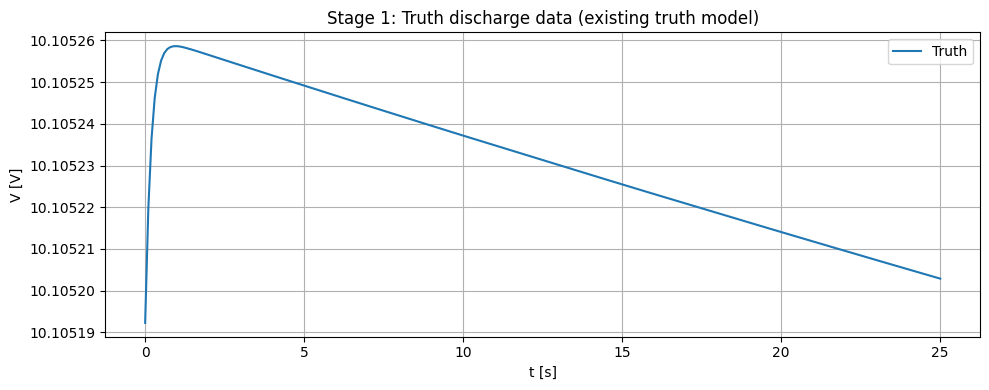

Shapes: t (251,) U (251, 1) Y (251, 1)

Stage 2: Fit ONLY surrogate V (thetaZ + R), A and B fixed to truth
Stage 2 pre-fit max|err|: 0.05972265607674743


  0%|                        |

Solving NLP with Adam (22 optimization variables) ...


100%|████████████████████████|
    f =   0.000002, f* =  0.000001, |grad f| =  0.001242, iter = 1200


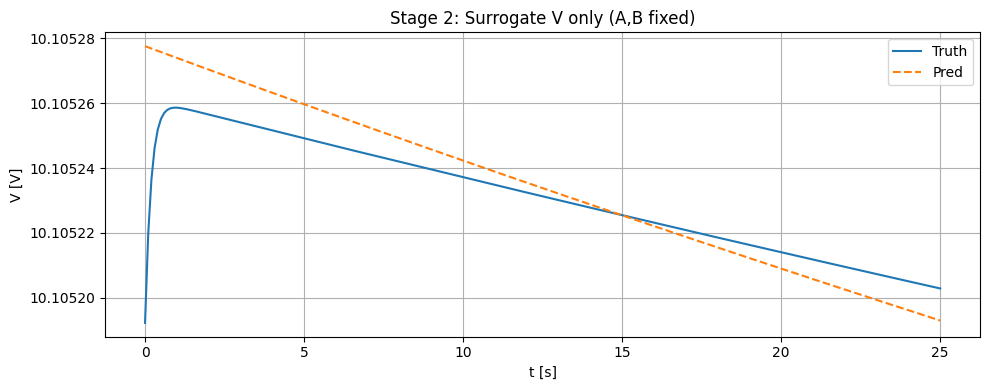


Stage 2 learned surrogate params:
  thetaZ_hat = [a,b,c,d,e,f,g]
  [-0.02839528  2.94112707 -1.52147336  0.02838882  2.99955209 -1.45775224
 10.13317771]
  Rcell_hat  = 0.009703801262646593
Stage 2 stats:
  max|err|: 8.534322384079474e-05
  MSE     : 1.1545992144363978e-10

Stage 3: Fit FULL A,B + surrogate V from RANDOM init
Stage 3 pre-fit max|err|: 14.763386943595332


  0%|                        |

Solving NLP with Adam (33 optimization variables) ...


100%|████████████████████████|
    f =  67.638110, f* =  67.638110, |grad f| =  40.143666, iter = 1200


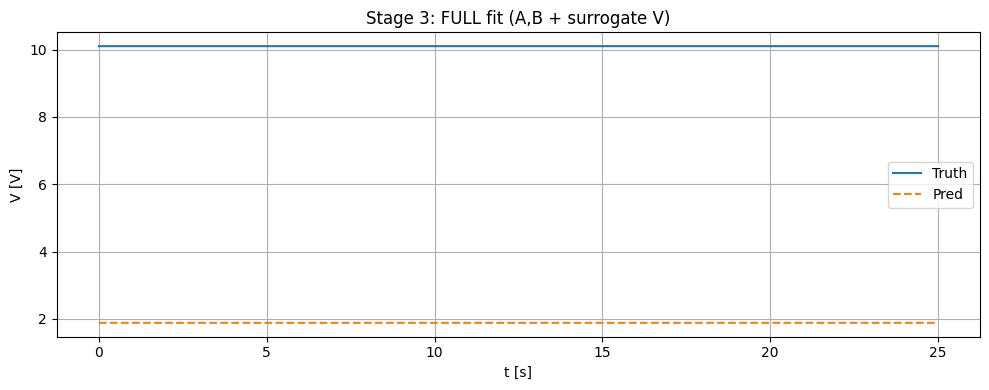


Stage 3 learned parameters:
  thetaA_hat (θ1..θ7)  = [0.36853488 1.04232729 1.05320927 1.00511279 0.96114709 1.02305424
 1.18303353]
  thetaB_hat (θ8..θ11) = [ 1.56896539  0.84570808 -0.15949594 -0.04973152]
  thetaZ_hat (a..g)    = [-1.18333441 -2.31084047 -1.25724522 -1.8222803  -1.34761349 -1.25333584
  0.99504309]
  Rcell_hat            = 0.34272448240398334

Stage 3 stats:
  max|err|: 8.224759018220832
  MSE     : 67.63810757605954


  0%|                        |

Solving NLP with Adam (33 optimization variables) ...


100%|████████████████████████|
    f =  117.078688, f* =  117.078688, |grad f| =  48.341624, iter = 600
  0%|                        |

Solving NLP with Adam (33 optimization variables) ...


...

Solving NLP with Adam (33 optimization variables) ...


100%|████████████████████████|
    f =  112.339081, f* =  112.339081, |grad f| =  59.319222, iter = 600
  0%|                        |

Solving NLP with Adam (33 optimization variables) ...


100%|████████████████████████|
    f =  146.917019, f* =  146.917019, |grad f| =  65.895903, iter = 600



=== Stage 3 multi-start summary (sorted by MSE) ===
 trial   pre_max  post_max        mse
     1 12.415572  9.205886  84.744280
     6 13.293718  9.864121  97.281704
     7 13.169775 10.580660 111.942314
     8 14.374982 10.600132 112.339079
     0 13.474138 10.820442 117.078685
     9 15.508666 12.121557 146.917016
     4 16.159876 12.244158 149.909078
     3 16.116737 12.490986 156.010010
     5 15.988910 12.723006 161.861691
     2 16.389263 12.750883 162.570596


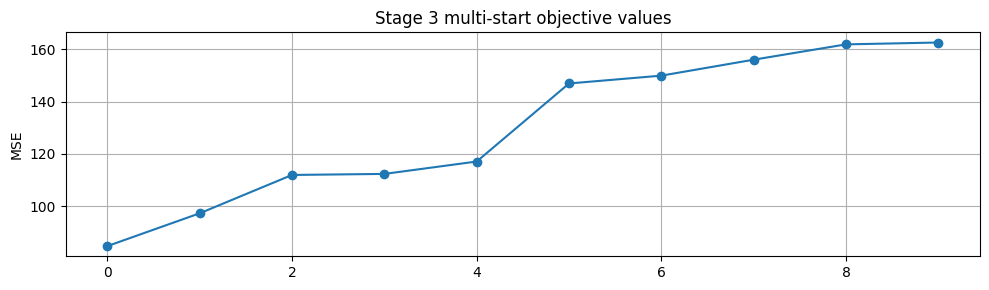

In [ ]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# UPDATED PER SUPERVISOR IDEA:
#   Replace the nonlinear "Z" part of V with a 7-parameter surrogate:
#       Z_hat(xp,xn) = a*tanh(b*xp + c) + d*tanh(e*xn + f) + g
#
# Keep the EXACT same staged experiment structure:
#
#   Stage 1) Generate synthetic "truth" discharge data from existing model
#            (Config + control.nlsys + terminal_voltage_truth).
#
#   Stage 2) Keep A and B EXACTLY equal to truth A_true, B_true.
#            Identify ONLY surrogate-voltage parameters:
#               thetaZ = [a,b,c,d,e,f,g]  (7 params)
#               + thetaR = [Rcell]        (1 param, positive)
#            Total Stage-2 params = 8.
#
#   Stage 3) Identify EVERYTHING:
#            A(θ1..θ7), B(θ8..θ11), and surrogate-voltage (θ12..θ19) where:
#               θ12..θ18 = [a,b,c,d,e,f,g]
#               θ19      = [Rcell] (positive)
#            Total Stage-3 params = 7 + 4 + 8 = 19.
#
# Notes:
#   - Truth generator voltage is unchanged (full OCV + BV + dphi_e + ohmic).
#   - Surrogate is fit against truth voltage by learning Z_hat and Rcell.
#   - For strict substitution: in JAX model, V_pack = Z_hat(xp,xn) - Ns*I*Rcell
#   - Constant-current identifiability can still be tricky, but we reduced V params.
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    """
    TRUTH voltage (unchanged): (Up-Un)+BV+dphi_e+ohmic, times N_series.
    """
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data (existing truth model)
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=25,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# --------- safe transforms ----------
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    """
    thetaA = [θ1..θ7] with θi > 0
    A is 14x14 block structure: cn(4), cp(4), ce(6)
    """
    th1, th2, th3, th4, th5, th6, th7 = thetaA

    A = jnp.zeros((14, 14), dtype=DTYPE)

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    """
    thetaB = [θ8, θ9, θ10, θ11]
    B is 14x1:
      cn: last node gets 6θ8
      cp: last node gets 6θ9
      ce: first two get θ10; last two get θ11
    """
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# NEW: Surrogate Z_hat (7 params) + ohmic Rcell (positive)
#   Z_hat(xp,xn) = a*tanh(b*xp + c) + d*tanh(e*xn + f) + g
#   V_pack = Z_hat(xp,xn) - (N_series * I * Rcell)
#
# IMPORTANT CONVENTION (strict):
#   - Z_hat is treated as PACK-SCALE (already includes N_series).
#   - Ohmic term is PACK-SCALE by multiplying N_series.
# =========================================================
@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    """
    thetaZ = [a,b,c,d,e,f,g] (7,)
    Uses ONLY xp,xn from the state.
    Returns Z_hat at PACK scale.
    """
    a, b, c, d, e, f, g = thetaZ

    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)

    zhat = a * jnp.tanh(b * xp + c) + d * jnp.tanh(e * xn + f) + g
    return zhat  # PACK-SCALE by convention

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    """
    raw_R is unconstrained; we make Rcell positive via pos().
    V_pack = Z_hat_pack(x) - N_series * I * Rcell
    """
    Zhat_pack = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    Vohm_pack = -DTYPE(CFG.N_series) * I * Rcell
    return Zhat_pack + Vohm_pack

# =========================================================
# Utility: a reasonable thetaZ0 init from truth OCV shapes
# (kept simple; you can change later if needed)
# =========================================================
def make_thetaZ0_default(Y_np_1d: np.ndarray) -> np.ndarray:
    """
    A simple init:
      g0 = mean(V)
      a0,d0 = quarter-range
      b0,e0 = 3
      c0,f0 = -1.5 (center transition ~0.5)
    This is not "truth"—just a stable starting point.
    """
    v = np.asarray(Y_np_1d).reshape(-1)
    vmin, vmax, vmean = float(np.min(v)), float(np.max(v)), float(np.mean(v))
    amp = 0.25 * (vmax - vmin + 1e-12)
    b0 = 3.0; e0 = 3.0
    c0 = -0.5 * b0
    f0 = -0.5 * e0
    g0 = vmean
    return np.array([amp, b0, c0, amp, e0, f0, g0], dtype=np.float64)

# =========================================================
# Stage 2: Fit ONLY surrogate voltage (thetaZ + R) with A,B fixed
# =========================================================
print("\n==============================")
print("Stage 2: Fit ONLY surrogate V (thetaZ + R), A and B fixed to truth")
print("==============================")

# Build truth A,B and freeze them into JAX constants
_, A_true_np, B_true_np, _, _ = assemble_system(CFG)
A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

# Stage-2 params:
#   thetaZ (7,) + raw_R (1,)
thetaZ0 = make_thetaZ0_default(Y_np[:, 0])
raw_R0 = np.array([np.log(1e-2)], dtype=np.float64)  # unconstrained; pos(raw_R) makes it positive

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ, raw_R) = params
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R[0])
    return jnp.array([V], dtype=DTYPE)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=1200, lbfgs_epochs=0, adam_eta=1e-3)

modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
print("Stage 2 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage2) - Y_np))))

modelZ.fit(Y_np, U_np, t_np)

Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2: Surrogate V only (A,B fixed)")

thetaZ_hat = np.asarray(modelZ.params[0]).reshape(-1)
raw_R_hat = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat = float(np.asarray(pos(jnp.array(raw_R_hat, dtype=DTYPE), 1e-12)))

print("\nStage 2 learned surrogate params:")
print("  thetaZ_hat = [a,b,c,d,e,f,g]")
print(" ", thetaZ_hat)
print("  Rcell_hat  =", R_hat)

err2 = np.asarray(Yhat_stage2) - Y_np
print("Stage 2 stats:")
print("  max|err|:", float(np.max(np.abs(err2))))
print("  MSE     :", float(np.mean(err2**2)))

# =========================================================
# Stage 3: Fit FULL (A,B) + surrogate voltage from RANDOM init
#   Total params:
#     thetaA: 7 positive  (via exp on rawA)
#     thetaB: 4 signed
#     thetaZ: 7 free
#     raw_R : 1 (positive via pos)
#   Total = 19
# =========================================================
print("\n==============================")
print("Stage 3: Fit FULL A,B + surrogate V from RANDOM init")
print("==============================")

def unpack_theta19(raw_theta: jnp.ndarray):
    """
    raw_theta length = 19:
      raw[0:7]   -> thetaA positive via exp
      raw[7:11]  -> thetaB signed
      raw[11:18] -> thetaZ (a..g)
      raw[18]    -> raw_R (positive via pos)
    """
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    raw_R = raw_theta[18]
    thetaA = jnp.exp(rawA)
    thetaB = rawB
    return thetaA, thetaB, thetaZ, raw_R

@jax.jit
def state_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, raw_R = unpack_theta19(raw_theta)
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R)
    return jnp.array([V], dtype=DTYPE)

# RANDOM init (repeatable via seed)
seed = 0
rng = np.random.default_rng(seed)

# Keep exp(rawA) safe by using moderate variance
raw_init19 = rng.normal(0.0, 0.5, size=(19,)).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
model19.init(params=[raw_init19], x0=np.array(X[0], dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-8)

model19.optimization(adam_epochs=1200, lbfgs_epochs=0, adam_eta=1e-3)

model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model19.predict(model19.x0, U_np, t_np)
print("Stage 3 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage3) - Y_np))))

model19.fit(Y_np, U_np, t_np)

Yhat19, _ = model19.predict(model19.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat19, title="Stage 3: FULL fit (A,B + surrogate V)")

# Report learned parameters in interpretable space
raw_hat19 = np.asarray(model19.params[0]).reshape(-1)

thetaA_hat = np.exp(raw_hat19[0:7])
thetaB_hat = raw_hat19[7:11]
thetaZ_hat3 = raw_hat19[11:18]
raw_R_hat3 = float(raw_hat19[18])
R_hat3 = float(np.asarray(pos(jnp.array(raw_R_hat3, dtype=DTYPE), 1e-12)))

print("\nStage 3 learned parameters:")
print("  thetaA_hat (θ1..θ7)  =", thetaA_hat)
print("  thetaB_hat (θ8..θ11) =", thetaB_hat)
print("  thetaZ_hat (a..g)    =", thetaZ_hat3)
print("  Rcell_hat            =", R_hat3)

err3 = np.asarray(Yhat19) - Y_np
print("\nStage 3 stats:")
print("  max|err|:", float(np.max(np.abs(err3))))
print("  MSE     :", float(np.mean(err3**2)))

# =========================================================
# Optional: Multi-start for FULL 19 params (random restarts)
# =========================================================
def multistart_full19(n_trials=5, seed=0, scale=0.5,
                      adam_epochs=800, adam_eta=1e-3,
                      rho_th=1e-8):
    rng = np.random.default_rng(seed)
    rows = []

    for k in range(n_trials):
        raw_init_k = rng.normal(0.0, scale, size=(19,)).astype(np.float64)

        m = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
        m.init(params=[raw_init_k], x0=np.array(X[0], dtype=np.float64))

        try:
            m.loss(rho_x0=0.0, rho_th=rho_th, xsat=1e9)
        except TypeError:
            m.loss(rho_x0=0.0, rho_th=rho_th)

        m.optimization(adam_epochs=adam_epochs, lbfgs_epochs=0, adam_eta=adam_eta)
        m.integration_options(
            ode_solver=diffrax.Tsit5(),
            dt0=float(t_np[1] - t_np[0]) / 50.0,
            max_steps=5_000_000,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
        )

        Y0k, _ = m.predict(m.x0, U_np, t_np)
        pre = float(np.max(np.abs(np.asarray(Y0k) - Y_np)))

        m.fit(Y_np, U_np, t_np)
        Yhk, _ = m.predict(m.x0, U_np, t_np)
        errk = np.asarray(Yhk) - Y_np
        post = float(np.max(np.abs(errk)))
        mse = float(np.mean(errk**2))

        rawk = np.asarray(m.params[0]).reshape(-1)
        thetaA_k = np.exp(rawk[0:7])
        thetaB_k = rawk[7:11]
        thetaZ_k = rawk[11:18]
        R_k = float(np.asarray(pos(jnp.array(float(rawk[18]), dtype=DTYPE), 1e-12)))

        rows.append(dict(
            trial=k, pre_max=pre, post_max=post, mse=mse,
            **{f"thA{i+1:02d}": thetaA_k[i] for i in range(7)},
            **{f"thB{i+8:02d}": thetaB_k[i] for i in range(4)},
            **{f"thZ{i+12:02d}": thetaZ_k[i] for i in range(7)},
            Rcell=R_k
        ))

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    print("\n=== Stage 3 multi-start summary (sorted by MSE) ===")
    print(df[["trial","pre_max","post_max","mse"]].head(10).to_string(index=False))
    return df

# # Uncomment if you want:
# df_ms19 = multistart_full19(n_trials=10, seed=1, scale=0.5, adam_epochs=600)
# plt.figure(figsize=(10,3))
# plt.plot(df_ms19["mse"].values, marker="o")
# plt.grid(True)
# plt.ylabel("MSE")
# plt.title("Stage 3 multi-start objective values")
# plt.tight_layout()
# plt.show()

Sanity:
  xp range: 0.4 0.40074580811003474
  xn range: 0.799254191889965 0.8
  ceL min : 999.637795630557  ceR min: 1000.0


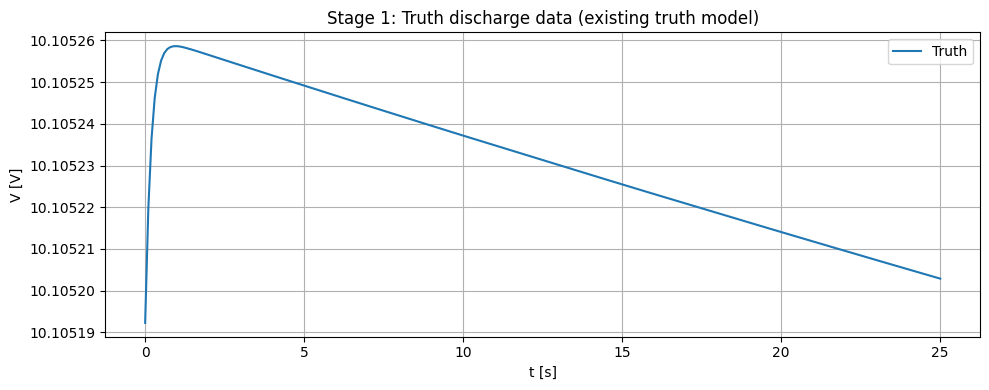

Shapes: t (251,) U (251, 1) Y (251, 1)

DEBUG: surrogate 'true' fitted on dataset
  mse_fit_surrogate_on_truth = 2.3373921512007846e-11
  thetaZ_true=[a,b,c,d,e,f,g] = [ 2.54143954e+06  1.67857143e+00 -4.00000000e+00  5.77098264e+03
  4.42857143e+00 -3.14285714e+00  6.84940069e+04]
  R_true = -410706.7985785054

Stage 2 (DEBUG): init near TRUE surrogate params
Stage 2 pre-fit max|err|: 2473127.230783119


  0%|                        |

Solving NLP with Adam (22 optimization variables) ...


100%|████████████████████████|
    f =  5938240953983.531250, f* =  5938240953983.531250, |grad f| =  398058320265.447266, iter = 600


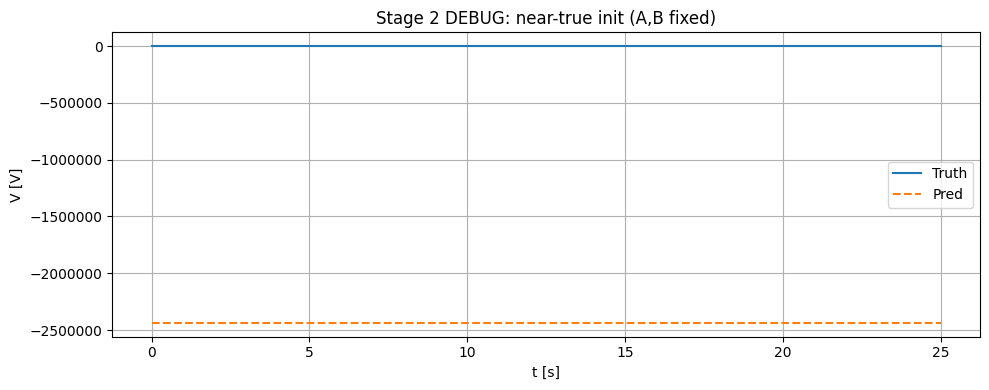


Stage 2 learned params:
  thetaZ_hat = [ 2.55102503e+06  2.36804258e+00 -3.39196382e+00  5.78979493e+03
  4.88087731e+00 -2.70080564e+00  7.11740864e+04]
  Rcell_hat  = 1.0001694544242277e-12
Stage 2 stats:
  max|err|: 2436915.803428794
  MSE     : 5938240917510.678

Stage 2 comparison vs 'true surrogate':
  thetaZ_true = [ 2.54143954e+06  1.67857143e+00 -4.00000000e+00  5.77098264e+03
  4.42857143e+00 -3.14285714e+00  6.84940069e+04]
  R_true      = -410706.7985785054

Stage 3 (DEBUG): init near TRUE A,B and TRUE surrogate params
Stage 3 pre-fit max|err|: 2464340.802021168


  0%|                        |

Solving NLP with Adam (33 optimization variables) ...


100%|████████████████████████|
    f =  5764870563108.401367, f* =  5764870563108.401367, |grad f| =  682405871557.781860, iter = 700


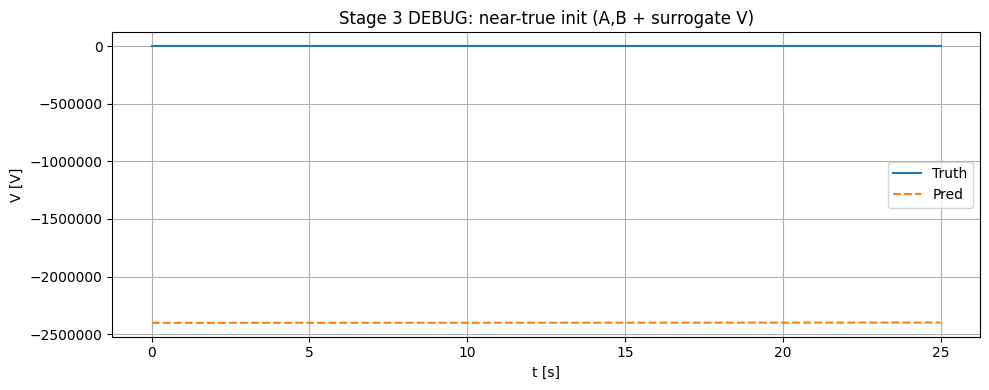


Stage 3 learned parameters:
  thetaA_hat (θ1..θ7)  = [2.18553238e-04 1.63565107e-04 2.43679838e+00 1.04128982e+00
 3.69461959e+00 1.06233870e+00 2.38219071e+00]
  thetaB_hat (θ8..θ11) = [ 0.5323538   0.95286905 -0.46740627  0.47484874]
  thetaZ_hat (a..g)    = [ 2.54143886e+06  2.49333671e+00 -3.16856358e+00  5.77171601e+03
  5.03343865e+00 -2.55504034e+00  6.84946956e+04]
  Rcell_hat            = 1.0001913520725581e-12

Stage 3 stats:
  max|err|: 2402499.4202254843
  MSE     : 5764870598230.962

Stage 3 comparison vs true (decoded from A_true/B_true and surrogate fit):
  thetaA_true = [4.00000000e-04 4.00000000e-04 3.85600000e+00 1.19012346e+00
 6.02500000e+00 1.19012346e+00 3.85600000e+00]
  thetaB_true = [-0.08291416  0.08291416 -0.85677962  0.85677962]
  thetaZ_true = [ 2.54143954e+06  1.67857143e+00 -4.00000000e+00  5.77098264e+03
  4.42857143e+00 -3.14285714e+00  6.84940069e+04]
  R_true      = -410706.7985785054


In [1]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# DEBUG MODE PER SUPERVISOR:
#   "Start optimization close to the TRUE parameters."
#   If it converges, code wiring is correct. If not, bug/scale mismatch.
#
# How we do "true" here (without touching the truth generator dynamics):
#   1) Compute "true" z_hat and Rcell by regressing on the truth data:
#        V_truth(t) ≈ a*tanh(b*xp(t)+c) + d*tanh(e*xn(t)+f) + g  - Ns*I*Rcell
#      where xp(t), xn(t) come from the truth states X(t).
#      This gives a consistent "ground-truth surrogate" for THIS dataset.
#
#   2) Stage 2:
#        A,B frozen to truth. Optimize ONLY (thetaZ, raw_R) starting near true.
#
#   3) Stage 3:
#        Optimize ALL 19 parameters starting near true A,B AND near true (thetaZ, raw_R).
#
# Multi-start section kept (commented out).
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    """
    TRUTH voltage (unchanged): (Up-Un)+BV+dphi_e+ohmic, times N_series.
    """
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data (existing truth model)
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=25,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# --------- safe transforms ----------
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA

    A = jnp.zeros((14, 14), dtype=DTYPE)

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# Surrogate Z_hat and voltage
# =========================================================
@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a, b, c, d, e, f, g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)
    return a * jnp.tanh(b * xp + c) + d * jnp.tanh(e * xn + f) + g  # PACK-scale

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    Zhat_pack = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    return Zhat_pack - DTYPE(CFG.N_series) * I * Rcell

# =========================================================
# DEBUG STEP: compute "true" surrogate params on THIS dataset
#   V ≈ a*tanh(b*xp+c) + d*tanh(e*xn+f) + g - Ns*I*R
# We'll do a small grid-search over (b,c,e,f) and then solve (a,d,g,R)
# by linear least squares for each grid point.
# This gives a reliable thetaZ_true-like for debug starts.
# =========================================================
def estimate_surrogate_truth_from_data(
    X: np.ndarray,
    Y: np.ndarray,
    I_const: float,
    Ns: int,
    csp_max: float,
    csn_max: float,
    # small "debug" grids (tighten/expand as you like)
    b_grid=np.linspace(0.5, 6.0, 15),
    c_grid=np.linspace(-4.0, 2.0, 15),
    e_grid=np.linspace(0.5, 6.0, 15),
    f_grid=np.linspace(-4.0, 2.0, 15),
):
    xp = np.clip(X[:, IDX["cp_surf"]] / csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(X[:, IDX["cn_surf"]] / csn_max, 1e-9, 1 - 1e-9)
    v = Y[:, 0].astype(np.float64)

    best = dict(mse=np.inf, thetaZ=None, R=None, bcfe=None)

    # target: v = a*T1 + d*T2 + g + (-Ns*I)*R
    # Unknowns [a, d, g, R] -> linear regression once T1,T2 fixed.
    ohm_col = (-float(Ns) * float(I_const)) * np.ones_like(v)

    for b in b_grid:
        for c in c_grid:
            T1 = np.tanh(b * xp + c)
            for e in e_grid:
                for f in f_grid:
                    T2 = np.tanh(e * xn + f)

                    Phi = np.column_stack([T1, T2, np.ones_like(v), ohm_col])
                    # Solve LS
                    w, *_ = np.linalg.lstsq(Phi, v, rcond=None)
                    a_hat, d_hat, g_hat, R_hat = w

                    vhat = Phi @ w
                    mse = float(np.mean((vhat - v) ** 2))

                    if mse < best["mse"]:
                        # thetaZ = [a,b,c,d,e,f,g]
                        best = dict(
                            mse=mse,
                            thetaZ=np.array([a_hat, b, c, d_hat, e, f, g_hat], dtype=np.float64),
                            R=float(R_hat),
                            bcfe=(b, c, e, f),
                        )

    return best

# Compute a "true surrogate" for debug (uses only data; does NOT change generator)
I_const = float(CFG.I_for_voltage)
sur_true = estimate_surrogate_truth_from_data(
    X=X,
    Y=Y,
    I_const=I_const,
    Ns=CFG.N_series,
    csp_max=CFG.csp_max,
    csn_max=CFG.csn_max,
)
thetaZ_true = sur_true["thetaZ"]
R_true = sur_true["R"]

print("\n==============================")
print("DEBUG: surrogate 'true' fitted on dataset")
print("==============================")
print("  mse_fit_surrogate_on_truth =", sur_true["mse"])
print("  thetaZ_true=[a,b,c,d,e,f,g] =", thetaZ_true)
print("  R_true =", R_true)

# Convert true R into raw_R so pos(raw_R) ≈ R_true
def inv_pos(y, floor=1e-12):
    # invert pos(x)=softplus(x)+floor approximately: softplus(x)=y-floor => x=log(exp(s)-1)
    s = max(float(y - floor), 1e-16)
    return np.log(np.expm1(s))

raw_R_true = inv_pos(R_true, 1e-12)

# =========================================================
# Helper: sample "close to true" initial guesses
#   Uses relative perturbation for most params, absolute for shifts.
# =========================================================
def sample_near_true(theta_true: np.ndarray, rng: np.random.Generator, rel=0.05, abs_=0.05):
    """
    theta_true: vector
    rel: relative noise scale (multiplicative) for nonzero entries
    abs_: additive noise scale (for any entries; good for c,f,g)
    """
    theta_true = np.asarray(theta_true, dtype=np.float64)
    noise_rel = rng.normal(0.0, rel, size=theta_true.shape)
    noise_abs = rng.normal(0.0, abs_, size=theta_true.shape)
    theta0 = theta_true * (1.0 + noise_rel) + noise_abs
    return theta0.astype(np.float64)

# =========================================================
# Stage 2: Fit ONLY surrogate voltage (thetaZ + R) with A,B fixed
#   DEBUG START: initialize near thetaZ_true and R_true
# =========================================================
print("\n==============================")
print("Stage 2 (DEBUG): init near TRUE surrogate params")
print("==============================")

# Build truth A,B and freeze them into JAX constants
_, A_true_np, B_true_np, _, _ = assemble_system(CFG)
A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ, raw_R) = params
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R[0])
    return jnp.array([V], dtype=DTYPE)

# Choose initial values close to "true"
rng = np.random.default_rng(0)
thetaZ0 = sample_near_true(thetaZ_true, rng, rel=0.03, abs_=0.02)
raw_R0 = np.array([raw_R_true + rng.normal(0.0, 0.05)], dtype=np.float64)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

# Keep epochs modest while debugging
modelZ.optimization(adam_epochs=600, lbfgs_epochs=0, adam_eta=1e-3)

modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=3_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
print("Stage 2 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage2) - Y_np))))

modelZ.fit(Y_np, U_np, t_np)

Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2 DEBUG: near-true init (A,B fixed)")

thetaZ_hat = np.asarray(modelZ.params[0]).reshape(-1)
raw_R_hat = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat = float(np.asarray(pos(jnp.array(raw_R_hat, dtype=DTYPE), 1e-12)))

err2 = np.asarray(Yhat_stage2) - Y_np
print("\nStage 2 learned params:")
print("  thetaZ_hat =", thetaZ_hat)
print("  Rcell_hat  =", R_hat)
print("Stage 2 stats:")
print("  max|err|:", float(np.max(np.abs(err2))))
print("  MSE     :", float(np.mean(err2**2)))

print("\nStage 2 comparison vs 'true surrogate':")
print("  thetaZ_true =", thetaZ_true)
print("  R_true      =", R_true)

# =========================================================
# Stage 3: Fit FULL (A,B) + surrogate voltage
#   DEBUG START: initialize raw_theta19 near true A,B and near true surrogate
# =========================================================
print("\n==============================")
print("Stage 3 (DEBUG): init near TRUE A,B and TRUE surrogate params")
print("==============================")

def unpack_theta19(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    raw_R = raw_theta[18]
    thetaA = jnp.exp(rawA)
    thetaB = rawB
    return thetaA, thetaB, thetaZ, raw_R

@jax.jit
def state_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, raw_R = unpack_theta19(raw_theta)
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R)
    return jnp.array([V], dtype=DTYPE)

# ---- Build "true" thetaA/thetaB from truth A,B to start near them ----
# From your builders:
#   An uses th1, Ap uses th2, Ae uses th3..th7 with:
#     th3 for w11-like = (De/eps)*(4/L1^2)  etc. BUT in your JAX Ae form,
#     those th3..th7 are already the "edge weights" not the physical De/eps directly.
#
# Since Stage 1 uses physical build_Ae(), we can back out the effective weights
# directly from A_true_np entries:
#   Ae_true[0,1] = +4*th3  => th3 = Ae_true[0,1]/4
#   Ae_true[1,2] = +16*th4 => th4 = Ae_true[1,2]/16
#   Ae_true[2,3] = +4*th5  => th5 = Ae_true[2,3]/4
#   Ae_true[3,4] = +16*th6 => th6 = Ae_true[3,4]/16
#   Ae_true[4,5] = +4*th7  => th7 = Ae_true[4,5]/4
#
# Similarly for An/Ap:
#   An_true[0,1] = +24*th1 => th1 = An_true[0,1]/24
#   Ap_true[0,1] = +24*th2 => th2 = Ap_true[0,1]/24
#
# For B:
#   B[3]=6*th8 => th8=B[3]/6 ; B[7]=6*th9 ; B[8]=th10 ; B[12]=th11
#
An_true = A_true_np[0:4, 0:4]
Ap_true = A_true_np[4:8, 4:8]
Ae_true = A_true_np[8:14, 8:14]
B_true_col = B_true_np[:, 0]

thetaA_true = np.array([
    float(An_true[0, 1] / 24.0),
    float(Ap_true[0, 1] / 24.0),
    float(Ae_true[0, 1] / 4.0),
    float(Ae_true[1, 2] / 16.0),
    float(Ae_true[2, 3] / 4.0),
    float(Ae_true[3, 4] / 16.0),
    float(Ae_true[4, 5] / 4.0),
], dtype=np.float64)

thetaB_true = np.array([
    float(B_true_col[3] / 6.0),
    float(B_true_col[7] / 6.0),
    float(B_true_col[8]),
    float(B_true_col[12]),
], dtype=np.float64)

# rawA is log(thetaA) because thetaA=exp(rawA)
rawA_true = np.log(np.maximum(thetaA_true, 1e-30))
rawB_true = thetaB_true.copy()  # signed
rawZ_true = thetaZ_true.copy()
rawR_true_scalar = float(raw_R_true)

# Sample close to true with tight ranges
rng = np.random.default_rng(1)
rawA0 = rawA_true + rng.normal(0.0, 0.03, size=(7,))
rawB0 = rawB_true + rng.normal(0.0, 0.03, size=(4,))
rawZ0 = rawZ_true + rng.normal(0.0, 0.03, size=(7,))
rawR0 = rawR_true_scalar + rng.normal(0.0, 0.05)

raw_init19 = np.concatenate([rawA0, rawB0, rawZ0, np.array([rawR0])]).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
model19.init(params=[raw_init19], x0=np.array(X[0], dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-8)

model19.optimization(adam_epochs=700, lbfgs_epochs=0, adam_eta=1e-3)

model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=3_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model19.predict(model19.x0, U_np, t_np)
print("Stage 3 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage3) - Y_np))))

model19.fit(Y_np, U_np, t_np)

Yhat19, _ = model19.predict(model19.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat19, title="Stage 3 DEBUG: near-true init (A,B + surrogate V)")

raw_hat19 = np.asarray(model19.params[0]).reshape(-1)
thetaA_hat = np.exp(raw_hat19[0:7])
thetaB_hat = raw_hat19[7:11]
thetaZ_hat3 = raw_hat19[11:18]
raw_R_hat3 = float(raw_hat19[18])
R_hat3 = float(np.asarray(pos(jnp.array(raw_R_hat3, dtype=DTYPE), 1e-12)))

err3 = np.asarray(Yhat19) - Y_np
print("\nStage 3 learned parameters:")
print("  thetaA_hat (θ1..θ7)  =", thetaA_hat)
print("  thetaB_hat (θ8..θ11) =", thetaB_hat)
print("  thetaZ_hat (a..g)    =", thetaZ_hat3)
print("  Rcell_hat            =", R_hat3)
print("\nStage 3 stats:")
print("  max|err|:", float(np.max(np.abs(err3))))
print("  MSE     :", float(np.mean(err3**2)))

print("\nStage 3 comparison vs true (decoded from A_true/B_true and surrogate fit):")
print("  thetaA_true =", thetaA_true)
print("  thetaB_true =", thetaB_true)
print("  thetaZ_true =", thetaZ_true)
print("  R_true      =", R_true)

# =========================================================
# Optional: Multi-start for FULL 19 params (random restarts)
# Keep commented out for now (per supervisor).
# =========================================================
def multistart_full19(n_trials=5, seed=0, scale=0.5,
                      adam_epochs=800, adam_eta=1e-3,
                      rho_th=1e-8):
    rng = np.random.default_rng(seed)
    rows = []

    for k in range(n_trials):
        raw_init_k = rng.normal(0.0, scale, size=(19,)).astype(np.float64)

        m = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
        m.init(params=[raw_init_k], x0=np.array(X[0], dtype=np.float64))

        try:
            m.loss(rho_x0=0.0, rho_th=rho_th, xsat=1e9)
        except TypeError:
            m.loss(rho_x0=0.0, rho_th=rho_th)

        m.optimization(adam_epochs=adam_epochs, lbfgs_epochs=0, adam_eta=adam_eta)
        m.integration_options(
            ode_solver=diffrax.Tsit5(),
            dt0=float(t_np[1] - t_np[0]) / 50.0,
            max_steps=5_000_000,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
        )

        Y0k, _ = m.predict(m.x0, U_np, t_np)
        pre = float(np.max(np.abs(np.asarray(Y0k) - Y_np)))

        m.fit(Y_np, U_np, t_np)
        Yhk, _ = m.predict(m.x0, U_np, t_np)
        errk = np.asarray(Yhk) - Y_np
        post = float(np.max(np.abs(errk)))
        mse = float(np.mean(errk**2))

        rows.append(dict(trial=k, pre_max=pre, post_max=post, mse=mse))

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    print("\n=== Stage 3 multi-start summary (sorted by MSE) ===")
    print(df[["trial","pre_max","post_max","mse"]].head(10).to_string(index=False))
    return df

# # Uncomment if you want later:
# df_ms19 = multistart_full19(n_trials=10, seed=1, scale=0.5, adam_epochs=600)
# plt.figure(figsize=(10,3))
# plt.plot(df_ms19["mse"].values, marker="o")
# plt.grid(True)
# plt.ylabel("MSE")
# plt.title("Stage 3 multi-start objective values")
# plt.tight_layout()
# plt.show()

Sanity:
  xp range: 0.4 0.40074580811003474
  xn range: 0.799254191889965 0.8
  ceL min : 999.637795630557  ceR min: 1000.0


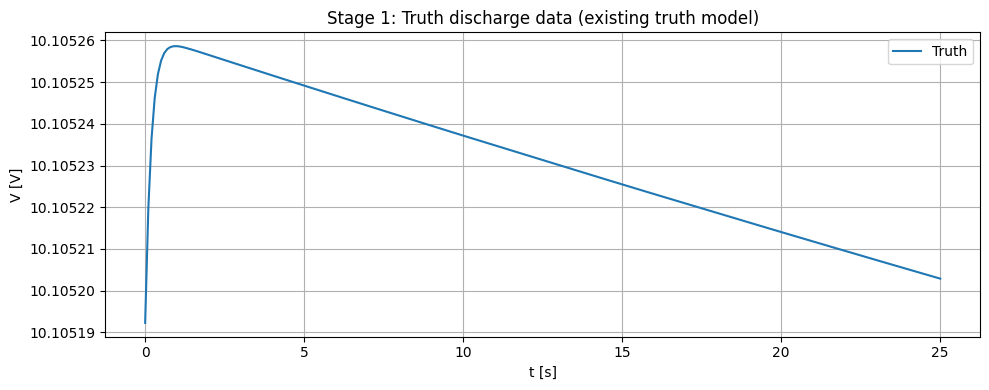


DEBUG: surrogate 'true' (NO-R) fitted on dataset
  mse_fit_surrogate_on_truth = 2.3374026925691003e-11
  thetaZ_true=[a,b,c,d,e,f,g_eff] = [ 2.54176966e+06  1.67857143e+00 -4.00000000e+00  5.77173227e+03
  4.42857143e+00 -3.14285714e+00  2.53306379e+06]

Stage 2 DEBUG: A,B fixed. Fit ONLY thetaZ (NO explicit R)
Stage 2 pre-fit max|err|: 58429.41316491061


  0%|                        |

Solving NLP with Adam (21 optimization variables) ...


100%|████████████████████████|
    f =  2390523005.806029, f* =  2390523005.806029, |grad f| =  549894861.573973, iter = 600


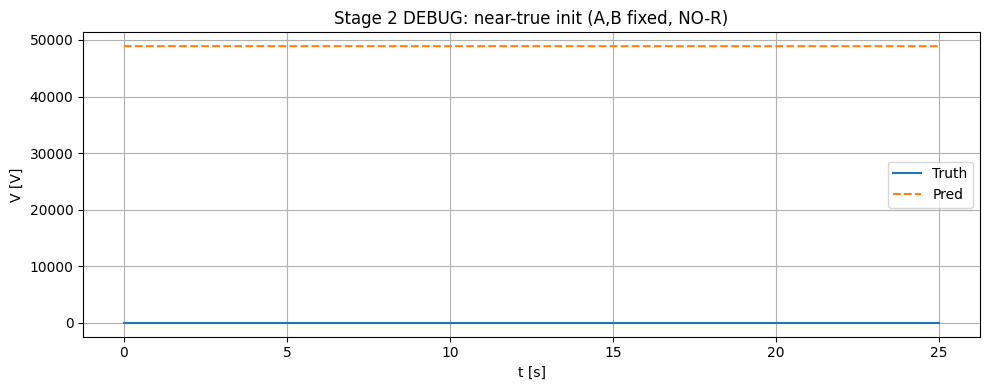


Stage 2 learned thetaZ: [ 2.54816180e+06  1.17620536e+00 -4.55478464e+00  5.78419200e+03
  3.81599498e+00 -3.75438245e+00  2.59912550e+06]
Stage 2 stats: max|err| = 48895.65451868366  MSE = 2390390557.3887362
Stage 2 compare vs thetaZ_true: [ 2.54176966e+06  1.67857143e+00 -4.00000000e+00  5.77173227e+03
  4.42857143e+00 -3.14285714e+00  2.53306379e+06]

Stage 3 DEBUG: Fit A,B + thetaZ (18 params, NO explicit R)
Stage 3 pre-fit max|err|: 100.02353710706105


  0%|                        |

Solving NLP with Adam (32 optimization variables) ...


100%|████████████████████████|
    f =  128790.847817, f* =  128770.384244, |grad f| =  137041.331656, iter = 700


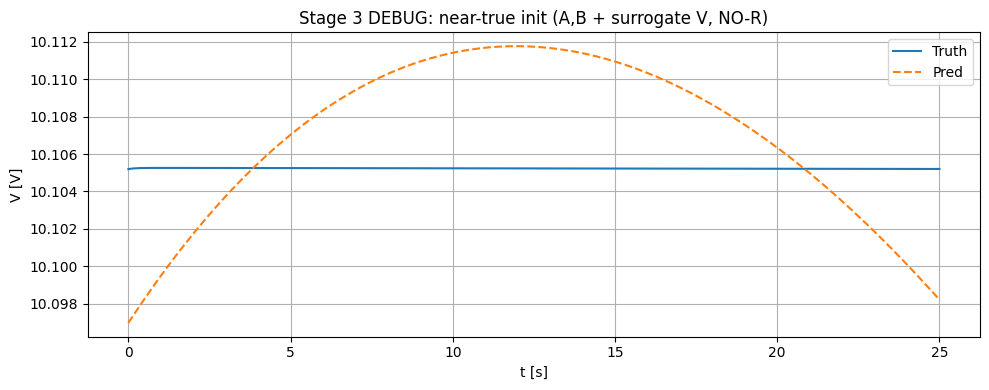


Stage 3 learned parameters:
  thetaA_hat (θ1..θ7)  = [3.95019093e-04 4.18253735e-04 2.45794668e+00 1.04239438e+00
 3.73099939e+00 1.06395047e+00 2.40266792e+00]
  thetaB_hat (θ8..θ11) = [-0.0787846   0.0803478  -0.4739195   0.48141456]
  thetaZ_hat (a..g_eff) = [ 2.54176966e+06  1.66017578e+00 -4.00117119e+00  5.77172152e+03
  4.45039878e+00 -3.13781024e+00  2.53306378e+06]
Stage 3 stats: max|err| = 0.008208294648124337  MSE = 2.1199245970852523e-05

Stage 3 comparison vs true:
  thetaA_true = [4.00000000e-04 4.00000000e-04 3.85600000e+00 1.19012346e+00
 6.02500000e+00 1.19012346e+00 3.85600000e+00]
  thetaB_true = [-0.08291416  0.08291416 -0.85677962  0.85677962]
  thetaZ_true = [ 2.54176966e+06  1.67857143e+00 -4.00000000e+00  5.77173227e+03
  4.42857143e+00 -3.14285714e+00  2.53306379e+06]


In [2]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# DEBUG MODE PER SUPERVISOR (FIXED):
#   Constant-current data cannot identify g and R separately because
#   both appear as constant offsets. So for debugging correctness we:
#
#   1) Fit a "dataset-consistent true surrogate" WITHOUT R:
#        V(t) ≈ a*tanh(b*xp+c) + d*tanh(e*xn+f) + g_eff
#      where g_eff = g - Ns*I*R is a single constant offset.
#
#   2) Stage 2: A,B frozen to truth. Fit ONLY thetaZ=[a,b,c,d,e,f,g_eff].
#
#   3) Stage 3: Fit A(7), B(4), and thetaZ(7) = total 18 params.
#
# Later (NOT NOW): if you want Rcell separately, you MUST use time-varying I(t).
# Multi-start code kept commented out for later.
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max
    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw
    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 25,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=25,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)
sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    A = jnp.zeros((14, 14), dtype=DTYPE)

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# Surrogate Z_hat (NO explicit R in DEBUG constant-I mode)
#   Z_hat(xp,xn) = a*tanh(b*xp + c) + d*tanh(e*xn + f) + g_eff
# =========================================================
@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a, b, c, d, e, f, g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)
    return a * jnp.tanh(b * xp + c) + d * jnp.tanh(e * xn + f) + g  # PACK-scale

# =========================================================
# DEBUG: compute "true surrogate params" on THIS dataset WITHOUT R
#   V ≈ a*T1 + d*T2 + g_eff   (g_eff absorbs -Ns*I*R)
# We'll grid-search (b,c,e,f) then LS for (a,d,g_eff).
# =========================================================
def estimate_surrogate_truth_noR(
    X: np.ndarray,
    Y: np.ndarray,
    csp_max: float,
    csn_max: float,
    b_grid=np.linspace(0.5, 6.0, 15),
    c_grid=np.linspace(-4.0, 2.0, 15),
    e_grid=np.linspace(0.5, 6.0, 15),
    f_grid=np.linspace(-4.0, 2.0, 15),
):
    xp = np.clip(X[:, IDX["cp_surf"]] / csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(X[:, IDX["cn_surf"]] / csn_max, 1e-9, 1 - 1e-9)
    v = Y[:, 0].astype(np.float64)

    best = dict(mse=np.inf, thetaZ=None, bcfe=None)

    for b in b_grid:
        for c in c_grid:
            T1 = np.tanh(b * xp + c)
            for e in e_grid:
                for f in f_grid:
                    T2 = np.tanh(e * xn + f)

                    Phi = np.column_stack([T1, T2, np.ones_like(v)])  # [a, d, g_eff]
                    w, *_ = np.linalg.lstsq(Phi, v, rcond=None)
                    a_hat, d_hat, g_hat = w

                    vhat = Phi @ w
                    mse = float(np.mean((vhat - v) ** 2))
                    if mse < best["mse"]:
                        best = dict(
                            mse=mse,
                            thetaZ=np.array([a_hat, b, c, d_hat, e, f, g_hat], dtype=np.float64),
                            bcfe=(b, c, e, f),
                        )
    return best

sur_true = estimate_surrogate_truth_noR(X=X, Y=Y, csp_max=CFG.csp_max, csn_max=CFG.csn_max)
thetaZ_true = sur_true["thetaZ"]

print("\n==============================")
print("DEBUG: surrogate 'true' (NO-R) fitted on dataset")
print("==============================")
print("  mse_fit_surrogate_on_truth =", sur_true["mse"])
print("  thetaZ_true=[a,b,c,d,e,f,g_eff] =", thetaZ_true)

def sample_near_true(theta_true: np.ndarray, rng: np.random.Generator, rel=0.03, abs_=0.02):
    theta_true = np.asarray(theta_true, dtype=np.float64)
    noise_rel = rng.normal(0.0, rel, size=theta_true.shape)
    noise_abs = rng.normal(0.0, abs_, size=theta_true.shape)
    return (theta_true * (1.0 + noise_rel) + noise_abs).astype(np.float64)

# =========================================================
# Stage 2 (DEBUG): A,B fixed. Fit ONLY thetaZ (7 params)
# =========================================================
print("\n==============================")
print("Stage 2 DEBUG: A,B fixed. Fit ONLY thetaZ (NO explicit R)")
print("==============================")

_, A_true_np, B_true_np, _, _ = assemble_system(CFG)
A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ,) = params
    V = zhat_pack_from_thetaZ(x, thetaZ)
    return jnp.array([V], dtype=DTYPE)

rng = np.random.default_rng(0)
thetaZ0 = sample_near_true(thetaZ_true, rng, rel=0.02, abs_=0.01)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=600, lbfgs_epochs=0, adam_eta=1e-3)
modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=3_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
print("Stage 2 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage2) - Y_np))))

modelZ.fit(Y_np, U_np, t_np)

Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2 DEBUG: near-true init (A,B fixed, NO-R)")

thetaZ_hat = np.asarray(modelZ.params[0]).reshape(-1)
err2 = np.asarray(Yhat_stage2) - Y_np
print("\nStage 2 learned thetaZ:", thetaZ_hat)
print("Stage 2 stats: max|err| =", float(np.max(np.abs(err2))), " MSE =", float(np.mean(err2**2)))
print("Stage 2 compare vs thetaZ_true:", thetaZ_true)

# =========================================================
# Stage 3 (DEBUG): Fit A(7), B(4), thetaZ(7) = 18 params
# =========================================================
print("\n==============================")
print("Stage 3 DEBUG: Fit A,B + thetaZ (18 params, NO explicit R)")
print("==============================")

def unpack_theta18(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    thetaA = jnp.exp(rawA)
    thetaB = rawB
    return thetaA, thetaB, thetaZ

@jax.jit
def state_fcn_full18(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _ = unpack_theta18(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full18(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ = unpack_theta18(raw_theta)
    V = zhat_pack_from_thetaZ(x, thetaZ)
    return jnp.array([V], dtype=DTYPE)

# Decode "true" thetaA/thetaB from A_true/B_true (same as your method)
An_true = A_true_np[0:4, 0:4]
Ap_true = A_true_np[4:8, 4:8]
Ae_true = A_true_np[8:14, 8:14]
B_true_col = B_true_np[:, 0]

thetaA_true = np.array([
    float(An_true[0, 1] / 24.0),
    float(Ap_true[0, 1] / 24.0),
    float(Ae_true[0, 1] / 4.0),
    float(Ae_true[1, 2] / 16.0),
    float(Ae_true[2, 3] / 4.0),
    float(Ae_true[3, 4] / 16.0),
    float(Ae_true[4, 5] / 4.0),
], dtype=np.float64)

thetaB_true = np.array([
    float(B_true_col[3] / 6.0),
    float(B_true_col[7] / 6.0),
    float(B_true_col[8]),
    float(B_true_col[12]),
], dtype=np.float64)

rawA_true = np.log(np.maximum(thetaA_true, 1e-30))
rawB_true = thetaB_true.copy()
rawZ_true = thetaZ_true.copy()

rng = np.random.default_rng(1)
rawA0 = rawA_true + rng.normal(0.0, 0.03, size=(7,))
rawB0 = rawB_true + rng.normal(0.0, 0.03, size=(4,))
rawZ0 = rawZ_true + rng.normal(0.0, 0.03, size=(7,))
raw_init18 = np.concatenate([rawA0, rawB0, rawZ0]).astype(np.float64)

model18 = CTModel(14, 1, 1, state_fcn=state_fcn_full18, output_fcn=output_fcn_full18)
model18.init(params=[raw_init18], x0=np.array(X[0], dtype=np.float64))

try:
    model18.loss(rho_x0=0.0, rho_th=1e-8, xsat=1e9)
except TypeError:
    model18.loss(rho_x0=0.0, rho_th=1e-8)

model18.optimization(adam_epochs=700, lbfgs_epochs=0, adam_eta=1e-3)
model18.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=3_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model18.predict(model18.x0, U_np, t_np)
print("Stage 3 pre-fit max|err|:", float(np.max(np.abs(np.asarray(Y0_stage3) - Y_np))))

model18.fit(Y_np, U_np, t_np)

Yhat18, _ = model18.predict(model18.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat18, title="Stage 3 DEBUG: near-true init (A,B + surrogate V, NO-R)")

raw_hat18 = np.asarray(model18.params[0]).reshape(-1)
thetaA_hat = np.exp(raw_hat18[0:7])
thetaB_hat = raw_hat18[7:11]
thetaZ_hat3 = raw_hat18[11:18]

err3 = np.asarray(Yhat18) - Y_np
print("\nStage 3 learned parameters:")
print("  thetaA_hat (θ1..θ7)  =", thetaA_hat)
print("  thetaB_hat (θ8..θ11) =", thetaB_hat)
print("  thetaZ_hat (a..g_eff) =", thetaZ_hat3)
print("Stage 3 stats: max|err| =", float(np.max(np.abs(err3))), " MSE =", float(np.mean(err3**2)))

print("\nStage 3 comparison vs true:")
print("  thetaA_true =", thetaA_true)
print("  thetaB_true =", thetaB_true)
print("  thetaZ_true =", thetaZ_true)

# =========================================================
# Optional: Multi-start (kept for later)
# =========================================================
# def multistart_full19(...):
#     pass